# Computer Vision: tagging and captioning images with Microsoft Azure

### Install Azure CV Client

In [84]:
# !pip install --upgrade azure-cognitiveservices-vision-computervision 
# !pip install opencv-python

### Import Global Variables and CV Client

In [20]:
from GlobalVariables import END_POINT, KEY_ONE as KEY
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from msrest.authentication import CognitiveServicesCredentials

In [167]:
from PIL import Image
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

### Use free pictures of Unsplash (unsplash.com) to check the CV Client 

In [198]:
# url = 'https://images.unsplash.com/photo-1548199973-03cce0bbc87b?ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&ixlib=rb-1.2.1&auto=format&fit=crop&w=1950&q=80'
url = 'https://images.unsplash.com/photo-1454793147212-9e7e57e89a4f?ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&ixlib=rb-1.2.1&auto=format&fit=crop&w=914&q=80'

In [199]:
image = Image.open(requests.get(url, stream=True).raw)

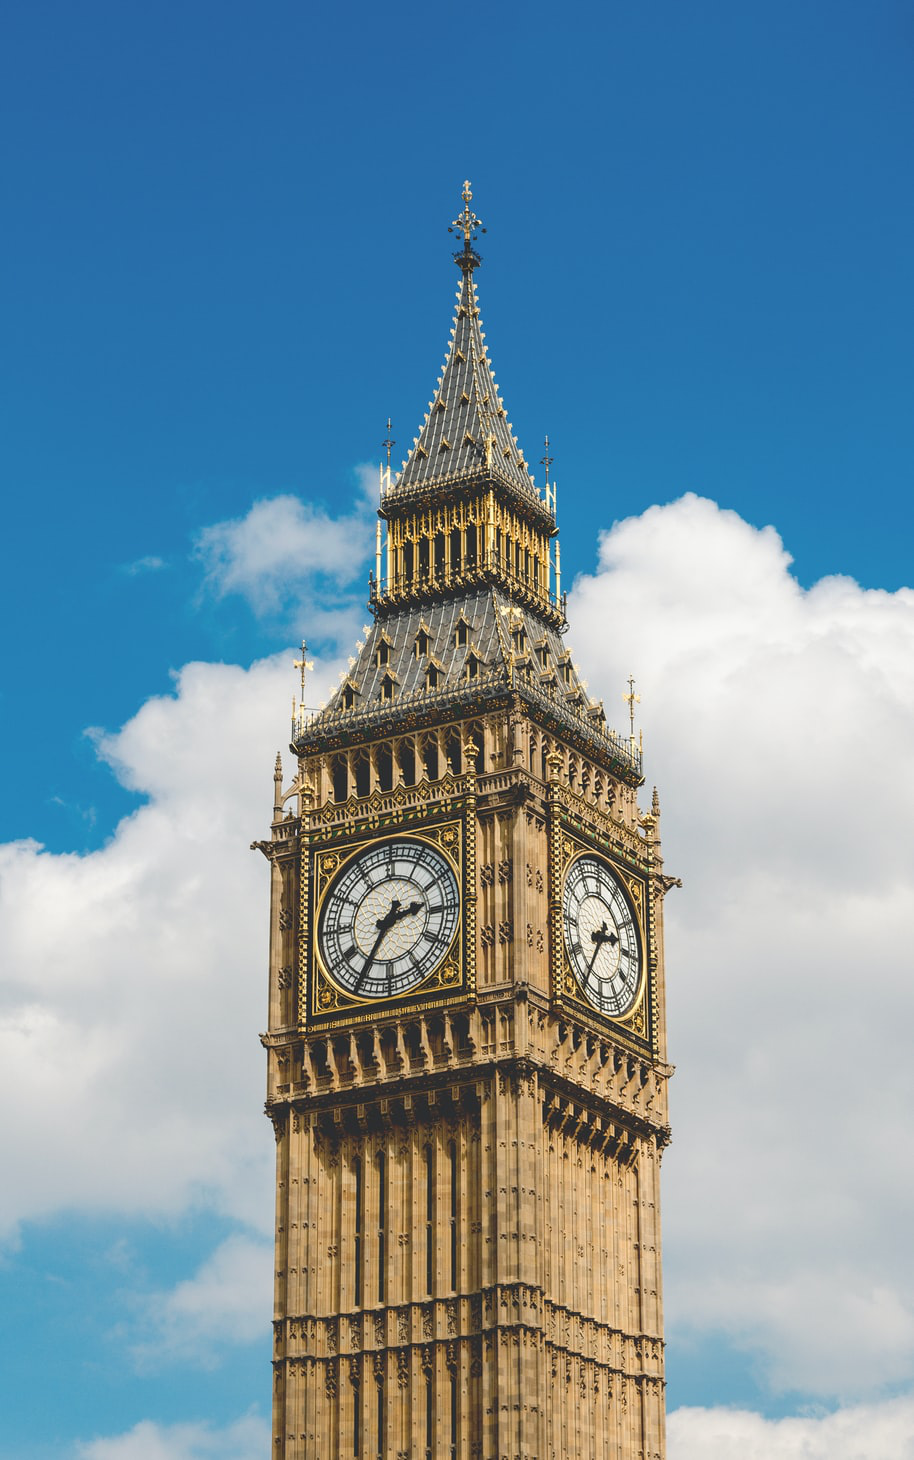

In [200]:
image

#### Initialize client

In [201]:
client = ComputerVisionClient(
    endpoint=END_POINT,
    credentials=CognitiveServicesCredentials(KEY)
    )

#### Image Description

In [202]:
describe = client.describe_image(url)

In [203]:
dir(describe)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_attribute_map',
 '_classify',
 '_create_xml_node',
 '_flatten_subtype',
 '_get_rest_key_parts',
 '_infer_class_models',
 '_subtype_map',
 '_validation',
 'additional_properties',
 'as_dict',
 'captions',
 'deserialize',
 'enable_additional_properties_sending',
 'from_dict',
 'is_xml_model',
 'metadata',
 'model_version',
 'request_id',
 'serialize',
 'tags',
 'validate']

In [204]:
describe.tags

['sky', 'outdoor', 'building', 'tower', 'tall', 'cloudy', 'clouds', 'day']

In [205]:
for caption in describe.captions:
    print(caption.text)
    print(caption.confidence)

a large clock tower with Big Ben in the background
0.47969499230384827


#### Object Detection

In [206]:
detect = client.detect_objects(url)

In [207]:
dir(detect)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_attribute_map',
 '_classify',
 '_create_xml_node',
 '_flatten_subtype',
 '_get_rest_key_parts',
 '_infer_class_models',
 '_subtype_map',
 '_validation',
 'additional_properties',
 'as_dict',
 'deserialize',
 'enable_additional_properties_sending',
 'from_dict',
 'is_xml_model',
 'metadata',
 'model_version',
 'objects',
 'request_id',
 'serialize',
 'validate']

In [208]:
for object in detect.objects:
    print(object.object_property)
    print(object.rectangle)

Wall clock
{'additional_properties': {}, 'x': 313, 'y': 836, 'w': 146, 'h': 177}
Wall clock
{'additional_properties': {}, 'x': 550, 'y': 859, 'w': 88, 'h': 162}


In [209]:
def add_boxes_to_image(image, predictions):
    for prediction in predictions:

        # print object name
        print(prediction.object_property)

        # set rectangle size
        x = prediction.rectangle.x 
        y = prediction.rectangle.y 
        width = prediction.rectangle.w 
        height = prediction.rectangle.h 

        # create subplot
        figure, ax = plt.subplots(1)
        ax.axis('off')

        # create rectangle
        rect = patches.Rectangle((x,y), width, height, edgecolor='r', facecolor="none")
        ax.imshow(image)
        ax.add_patch(rect)

        plt.show()

Wall clock


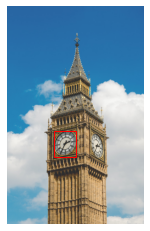

Wall clock


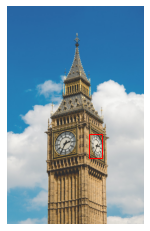

In [210]:
add_boxes_to_image(image, detect.objects)

#### Image analysis in the landmarks domain 

In [211]:
landmarks = client.analyze_image_by_domain('landmarks', url)

In [212]:
dir(landmarks)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_attribute_map',
 '_classify',
 '_create_xml_node',
 '_flatten_subtype',
 '_get_rest_key_parts',
 '_infer_class_models',
 '_subtype_map',
 '_validation',
 'additional_properties',
 'as_dict',
 'deserialize',
 'enable_additional_properties_sending',
 'from_dict',
 'is_xml_model',
 'metadata',
 'model_version',
 'request_id',
 'result',
 'serialize',
 'validate']

In [213]:
landmarks.result

{'landmarks': [{'name': 'Big Ben', 'confidence': 0.9976438879966736}]}

#### Image Analysis (general)

In [214]:
analyze = client.analyze_image(url)

In [215]:
dir(analyze)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_attribute_map',
 '_classify',
 '_create_xml_node',
 '_flatten_subtype',
 '_get_rest_key_parts',
 '_infer_class_models',
 '_subtype_map',
 '_validation',
 'additional_properties',
 'adult',
 'as_dict',
 'brands',
 'categories',
 'color',
 'description',
 'deserialize',
 'enable_additional_properties_sending',
 'faces',
 'from_dict',
 'image_type',
 'is_xml_model',
 'metadata',
 'model_version',
 'objects',
 'request_id',
 'serialize',
 'tags',
 'validate']

In [216]:
for category in analyze.categories:
    print(category)

{'additional_properties': {}, 'name': 'building_', 'score': 0.93359375, 'detail': None}
